## Regression Modeling • Math 189 • Wi 2026
### Due Date: Tue, Jun 7

> Members: $\color{green}{\text{ Charlene Hsu, Beau Luc, Havyn Nguyen, Naomi Metzler    }}$
> 
>
> 

In [1]:
import numpy as np
import scipy
from scipy import stats as stats
import pandas as pd
from itertools import combinations

import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Regression Modeling

> Objective: We want to see if census tracts(district seperation) with higher SNAP participation are more likely to experience low supermarket access? Does this relationship depend on whether the tract is an urban or rural area?

In [2]:
path = 'food_access_modeling.csv'
df_housing = pd.read_csv(path)

print(df_housing.head(5))

print(df_housing.shape[1])

   CensusTract    State          County  Urban urban_label  Pop2010  OHU2010  \
0   1001020100  Alabama  Autauga County      1       Urban     1912      693   
1   1001020200  Alabama  Autauga County      1       Urban     2170      743   
2   1001020300  Alabama  Autauga County      1       Urban     3373     1256   
3   1001020400  Alabama  Autauga County      1       Urban     4386     1722   
4   1001020500  Alabama  Autauga County      1       Urban    10766     4082   

   PovertyRate  MedianFamilyIncome  log_median_family_income  ...  \
0    11.336453             81250.0                 11.305286  ...   
1    17.876788             49000.0                 10.799576  ...   
2    15.046030             62609.0                 11.044664  ...   
3     2.845210             70607.0                 11.164885  ...   
4    15.150891             96334.0                 11.475577  ...   

   log_response  pct_children  pct_seniors  pct_white  pct_black  pct_asian  \
0      3.223299     26.51

### Fitting the model to a full model

In [30]:
response = 'pct_low_income_low_access'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_housing).fit()

full_model.summary()

full_formula:  pct_low_income_low_access ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     pct_low_income_low_access   R-squared:                       0.195
Model:                                   OLS   Adj. R-squared:                  0.195
Method:                        Least Squares   F-statistic:                     1022.
Date:                       Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                               10:49:37   Log-Likelihood:            -1.6394e+05
No. Observations:                      42156   AIC:                         3.279e+05
Df Residuals:                          42145   BIC:                         3.280e+05
Df Model:                                 10                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   80.5962      2.954     27.287      0.000      74.807      86.385
pct_snap                     0.0279      0.011      2.486      0.013       0.006       0.050
PovertyRate                  0.2540      0.010     24.435      0.000       0.234       0.274
log_median_family_income    -7.3335      0.254    -28.852      0.000      -7.832      -6.835
pct_no_vehicle              -0.2196      0.012    -18.094      0.000      -0.243      -0.196
Urban                        5.2818      0.168     31.496      0.000       4.953       5.610
pct_children                 0.1925      0.013     14.610      0.000       0.167       0.218
pct_seniors                  0.0727      0.010      7.452      0.000       0.054       0.092
pct_black                    0.0308      0.003      8.794      0.000       0.024       0.038
pct_hispanic                -0.0493      0.004    -12.900      0.000      -0.057      -0.042
pct_asian                   -0.0982      0.010    -10.125      0.000      -0.117      -0.079
==============================================================================
Omnibus:                     9774.425   Durbin-Watson:                   1.636
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24609.872
Skew:                           1.272   Prob(JB):                         0.00
Kurtosis:                       5.746   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Fitted Model to interaction model

Thus, we should changed our model such that model doesn't have issues with homoscedasticity, normality, linearity,and multicollinearity. We changed the formula so pct_snap:Urban and pct_no_vehicle:Urban are interaction terms. We also remove the pct_children, pct_seniors , pct_black, pct_hispanic, and pct_asian covariate terms.

In [44]:
response = 'log_response'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_snap:Urban + pct_no_vehicle:Urban"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_housing).fit()

print(full_model.summary())

full_formula:  log_response ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_snap:Urban + pct_no_vehicle:Urban
                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     786.9
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:25:22   Log-Likelihood:                -63586.
No. Observations:               42156   AIC:                         1.272e+05
Df Residuals:                   42148   BIC:                         1.273e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>

---

### Model Fitted to log_response and split into Urban and Rural models

In [42]:
adjusted_formula = ("log_response ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle")

#since we identified 1 as urban and 0 as rural
model_urban = smf.ols(adjusted_formula, data=df_housing[df_housing['Urban']==1]).fit()
print(model_urban.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     1120.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:24:45   Log-Likelihood:                -52105.
No. Observations:               34820   AIC:                         1.042e+05
Df Residuals:                   34815   BIC:                         1.043e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [43]:
#Set to 0 due to Rural
model_rural = smf.ols(adjusted_formula, data=df_housing[df_housing['Urban']==0]).fit()

print(model_rural.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     146.3
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          1.58e-120
Time:                        15:24:51   Log-Likelihood:                -11403.
No. Observations:                7336   AIC:                         2.282e+04
Df Residuals:                    7331   BIC:                         2.285e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

---

### Urban

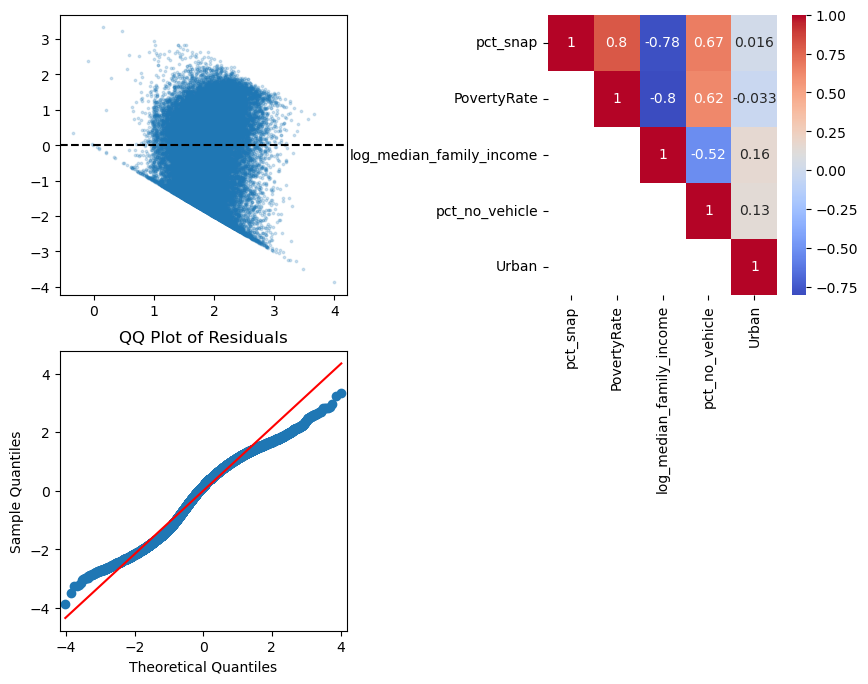

VIF: pct_snap:  3.997
VIF: PovertyRate:  3.847
VIF: log_median_family_income:  3.647
VIF: pct_no_vehicle:  1.986


In [35]:
covariates_term = ['pct_snap','PovertyRate','log_median_family_income','pct_no_vehicle','Urban']
#print(covariates_term)
corr_table = df_housing[covariates_term].corr() 

#plt.figure(figsize=(7, 5))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].scatter(model_urban.fittedvalues, model_urban.resid, s=3, alpha=0.2)
axes[0, 0].axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
sm.qqplot(model_urban.resid, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals")
sns.heatmap(corr_table, annot=True, cmap='coolwarm', mask=np.tril(corr_table, k=-1), ax=axes[0, 1])
axes[1, 1].set_title('Correlation matrix')
plt.subplots_adjust(wspace=0.7,hspace=0.2) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

exog = model_urban.model.exog
names = model_urban.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

### Rural

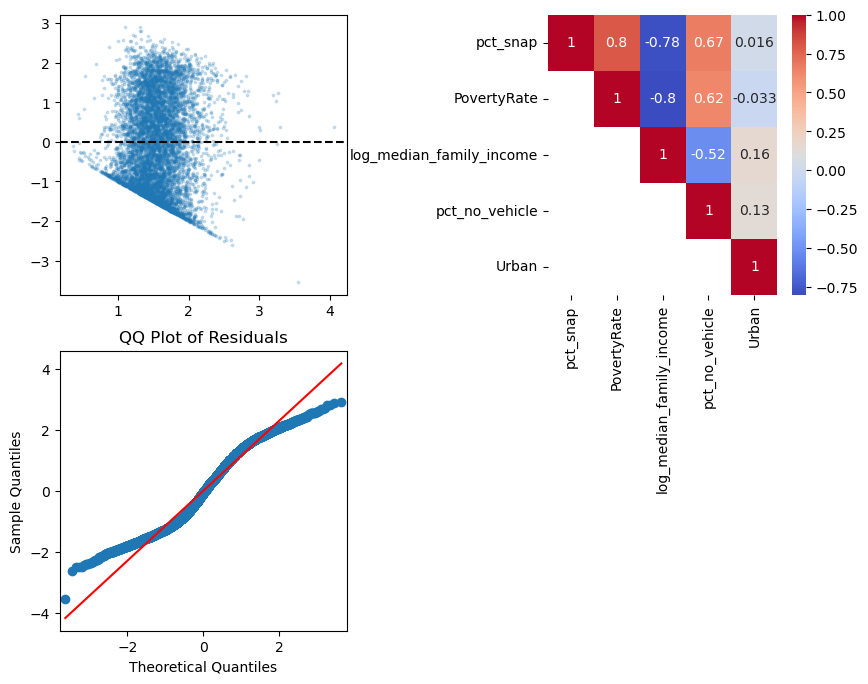

VIF: pct_snap:  2.686
VIF: PovertyRate:  3.202
VIF: log_median_family_income:  2.774
VIF: pct_no_vehicle:  1.467


In [37]:
covariates_term = ['pct_snap','PovertyRate','log_median_family_income','pct_no_vehicle','Urban']
#print(covariates_term)
corr_table = df_housing[covariates_term].corr() 

#plt.figure(figsize=(7, 5))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].scatter(model_rural.fittedvalues, model_rural.resid, s=3, alpha=0.2)
axes[0, 0].axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
sm.qqplot(model_rural.resid, line="s", ax=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals")
sns.heatmap(corr_table, annot=True, cmap='coolwarm', mask=np.tril(corr_table, k=-1), ax=axes[0, 1])
axes[1, 1].set_title('Correlation matrix')
plt.subplots_adjust(wspace=0.7,hspace=0.2) #text gets cramped in without this
axes[1,1].set_visible(False) #need only 3 graphs
plt.show()

exog = model_rural.model.exog
names = model_rural.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

---